# Spaced Repetition Modeli - Kesif ve Egitim Defteri

**Aktif/kullanilan veri seti: ASSISTments 2009-2010** (`assistments_sample_100k.csv`) - `train.py`, `app/model.py` ve `app/predict.py` su an bu defterdeki modeli kullaniyor. Ders/konu bazli, gercek matematik-ogretim platformu verisi.

Defterin sonunda **Ek** olarak, once denedigimiz ama vazgectigimiz Duolingo (kelime bazli) veri setiyle yasadigimiz surec de belgelendi - "neden vazgectik" sorusuna cevap olarak.

Colab/Jupyter mantigiyla: her hucreyi calistir, ciktiyi hemen altinda gor.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv("../assistments_sample_100k.csv")
print("Satir/sutun sayisi:", df.shape)
df.head()

Satir/sutun sayisi: (100000, 8)


,user_id,skill_name,opportunity,attempt_count,ms_first_response,overlap_time,hint_count,correct
0,77118,Addition and Subtraction Integers,966,1,2590,2590,0,1
1,89048,Conversion of Fraction Decimals Percents,3,1,7245,7245,0,1
2,86365,Equation Solving Two or Fewer Steps,19,1,2105,2105,0,1
3,96227,Counting Methods,10,1,11094,11203,0,0
4,78909,Subtraction Whole Numbers,8,1,2522553,2522553,0,1


## 1. Veri kalitesi ve hedef dagilimi

Sentetik verimizdeki gibi carpik olmayan, dengeli bir hedef ariyoruz.

In [2]:
print("Eksik deger:", df.isnull().sum().sum())
print("Farkli ogrenci sayisi:", df.user_id.nunique())
print("Farkli konu sayisi:", df.skill_name.nunique())
print()
print("correct dagilimi:")
print(df["correct"].value_counts(normalize=True))

Eksik deger: 0
Farkli ogrenci sayisi: 3728
Farkli konu sayisi: 109

correct dagilimi:
correct
1    0.69456
0    0.30544
Name: proportion, dtype: float64


## 2. Ozelliklerin `correct` ile korelasyonu

Hangi ham ozelligin gercekten sinyal tasidigini onceden kontrol ediyoruz.

In [3]:
numeric_cols = ["opportunity", "attempt_count", "ms_first_response", "overlap_time", "hint_count"]
print(df[numeric_cols + ["correct"]].corr()["correct"])

opportunity          0.053069
attempt_count       -0.055092
ms_first_response   -0.022780
overlap_time        -0.079740
hint_count          -0.542426
correct              1.000000
Name: correct, dtype: float64


## 3. Model: ikili siniflandirma (bu soruyu dogru cozecek mi?)

Yontem: `skill_name` (konu) one-hot encode edilir, sayisal ozellikler oldugu gibi girer, bunlar tek bir `Pipeline` icinde birlestirilir. `RandomForestClassifier` (yuzlerce karar agacinin ortalamasi) `correct`'i (dogru/yanlis) tahmin eder.

Veri **%70 egitim / %15 dogrulama / %15 test** olarak ucye bolunur (mentor talebi): egitim setiyle model kurulur, dogrulama seti gelistirme sirasinda modelin gormedigi veride nasil davrandigini kontrol eder, test seti ise SADECE en sonda bir kez nihai/tarafsiz performansi raporlamak icin kullanilir. Tek `train_test_split` cagrisi ucye bolemedigi icin iki asamada yapiyoruz: once %15 test ayrilir, kalan %85'in icinden 15/85 oraniyla dogrulama seti cikarilir - boylece final oranlar toplamin %70/%15/%15'i olur.

In [4]:
X = df[numeric_cols + ["skill_name"]]
y = df["correct"]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15 / 0.85, random_state=42, stratify=y_train_val
)
print(f"Egitim:    {len(X_train):>6} satir (%{100*len(X_train)/len(X):.0f})")
print(f"Dogrulama: {len(X_val):>6} satir (%{100*len(X_val)/len(X):.0f})")
print(f"Test:      {len(X_test):>6} satir (%{100*len(X_test)/len(X):.0f})")

preprocessor = ColumnTransformer(
    transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), ["skill_name"])],
    remainder="passthrough",
)
clf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight="balanced")
pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])
pipeline.fit(X_train, y_train)

proba_val = pipeline.predict_proba(X_val)[:, 1]
pred_val = pipeline.predict(X_val)
print()
print("=== Dogrulama sonuclari ===")
print(classification_report(y_val, pred_val, target_names=["yanlis (0)", "dogru (1)"]))
print("AUC (dogrulama):", round(roc_auc_score(y_val, proba_val), 3))

predictions = pipeline.predict(X_test)
probabilities = pipeline.predict_proba(X_test)[:, 1]
print()
print("=== Test sonuclari (nihai) ===")
print(classification_report(y_test, predictions, target_names=["yanlis (0)", "dogru (1)"]))
print("AUC (test):", round(roc_auc_score(y_test, probabilities), 3))

Egitim:     69999 satir (%70)
Dogrulama:  15001 satir (%15)
Test:       15000 satir (%15)



=== Dogrulama sonuclari ===
              precision    recall  f1-score   support

  yanlis (0)       0.99      0.76      0.86      4582
   dogru (1)       0.91      1.00      0.95     10419

    accuracy                           0.93     15001
   macro avg       0.95      0.88      0.91     15001
weighted avg       0.93      0.93      0.92     15001

AUC (dogrulama): 0.959



=== Test sonuclari (nihai) ===
              precision    recall  f1-score   support

  yanlis (0)       0.99      0.77      0.86      4582
   dogru (1)       0.91      1.00      0.95     10418

    accuracy                           0.93     15000
   macro avg       0.95      0.88      0.91     15000
weighted avg       0.93      0.93      0.92     15000

AUC (test): 0.958


## 4. Confusion matrix gorsellestirme

Hangi tur hatanin (yanlis alarm mi, kacirilan durum mu) daha sik oldugunu gormek icin.

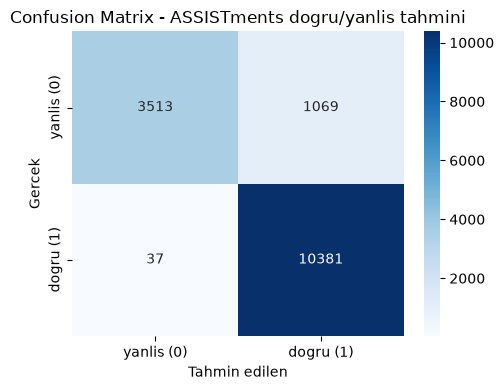

In [5]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["yanlis (0)", "dogru (1)"], yticklabels=["yanlis (0)", "dogru (1)"])
plt.xlabel("Tahmin edilen")
plt.ylabel("Gercek")
plt.title("Confusion Matrix - ASSISTments dogru/yanlis tahmini")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()

## 5. Feature importance - model hangi ozelliklere ne kadar guveniyor?

Random Forest, her ozelligin karar agaclarindaki bolme (split) noktalarinda ne kadar sik ve etkili kullanildigini `feature_importances_` ile raporlar. Burada iki soruyu cevapliyoruz: (1) davranissal ozellikler mi (tekrar sayisi, yanit suresi, ipucu) yoksa hangi konu oldugu mu (skill_name) daha belirleyici? (2) tekil olarak en onemli 10 ozellik nedir?

Davranissal ozellikler (opportunity/attempt/response-time/hint) toplam agirlik: 0.937
Konu (skill_name, 110 kategori toplami) toplam agirlik:                        0.063

En onemli ilk 10 ozellik:
                                                   feature  importance
                                  remainder__attempt_count    0.468793
                                     remainder__hint_count    0.297026
                                   remainder__overlap_time    0.079827
                              remainder__ms_first_response    0.064220
                                    remainder__opportunity    0.026849
          categorical__skill_name_Volume Rectangular Prism    0.008817
                    categorical__skill_name_Area Rectangle    0.005273
                     categorical__skill_name_Area Triangle    0.004751
                  categorical__skill_name_Counting Methods    0.004674
categorical__skill_name_Probability of Two Distinct Events    0.004330


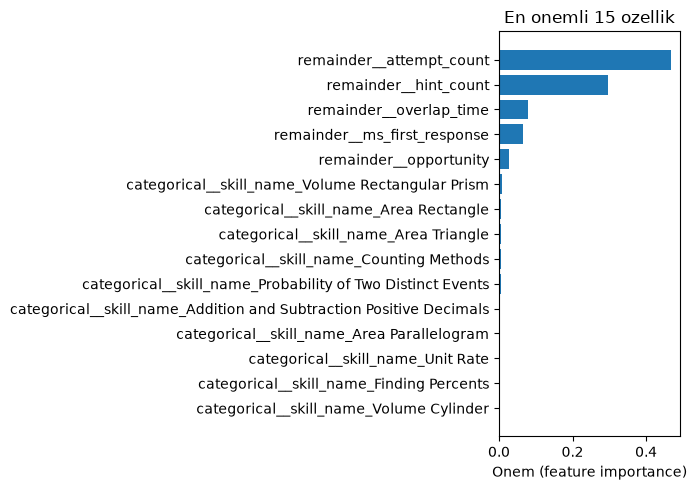

In [6]:
importances = pipeline.named_steps["model"].feature_importances_
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

numeric_importance = imp_df[imp_df.feature.str.startswith("remainder__")]["importance"].sum()
skill_importance = imp_df[imp_df.feature.str.startswith("categorical__")]["importance"].sum()
print(f"Davranissal ozellikler (opportunity/attempt/response-time/hint) toplam agirlik: {numeric_importance:.3f}")
print(f"Konu (skill_name, 110 kategori toplami) toplam agirlik:                        {skill_importance:.3f}")
print()
print("En onemli ilk 10 ozellik:")
print(imp_df.head(10).to_string(index=False))

plt.figure(figsize=(7, 5))
top15 = imp_df.head(15)
plt.barh(top15["feature"], top15["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Onem (feature importance)")
plt.title("En onemli 15 ozellik")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=100)
plt.show()


## 6. Model karsilastirmasi: Decision Tree vs Logistic Regression vs Random Forest vs XGBoost

Random Forest'in gercekten katki sagladigini dogrulamak icin ayni veri/bolunmeyle dort farkli model egitiyoruz:

- **Decision Tree**: Random Forest'in "tek agac" hali - kiyaslama icin onemli, ensemble'in (bagging) tek agaca gore ne kadar iyilestirdigini gosterir.
- **Logistic Regression**: dogrusal, basit bir baseline. Sayisal ozelliklerin olcekleri cok farkli oldugu icin (`opportunity` 1-3576, `hint_count` 0-7) once `StandardScaler` ile olceklendiriyoruz - aksi halde Logistic Regression haksiz yere kotu performans gosterebilir.
- **Random Forest**: elimizdeki mevcut model (bagging - agaclar birbirinden BAGIMSIZ, paralel egitilir).
- **XGBoost**: boosting ailesinin en populer uyesi - Random Forest'tan farkli olarak agaclar SIRAYLA egitilir, her yeni agac bir oncekinin hatalarina odaklanir. Sinif dengesizligini (`correct` %69.5/%30.5) `scale_pos_weight` ile ele aliyoruz - digerlerinde kullandigimiz `class_weight="balanced"`'in XGBoost karsiligi.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Decision Tree": Pipeline(steps=[
        ("preprocess", ColumnTransformer(
            transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), ["skill_name"])],
            remainder="passthrough",
        )),
        ("model", DecisionTreeClassifier(max_depth=12, random_state=42, class_weight="balanced")),
    ]),
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", ColumnTransformer(
            transformers=[
                ("categorical", OneHotEncoder(handle_unknown="ignore"), ["skill_name"]),
                ("numeric", StandardScaler(), numeric_cols),
            ],
        )),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    "Random Forest": pipeline,  # yukarida zaten egitilmis olan model
    "XGBoost": Pipeline(steps=[
        ("preprocess", ColumnTransformer(
            transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), ["skill_name"])],
            remainder="passthrough",
        )),
        ("model", XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            scale_pos_weight=scale_pos_weight, random_state=42,
            eval_metric="logloss",
        )),
    ]),
}

results = []
for name, model in models.items():
    if name != "Random Forest":
        model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    results.append({
        "model": name,
        "AUC": round(roc_auc_score(y_test, proba), 3),
        "accuracy": round((pred == y_test).mean(), 3),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


              model   AUC  accuracy
      Decision Tree 0.944     0.930
Logistic Regression 0.915     0.879
      Random Forest 0.958     0.926
            XGBoost 0.967     0.928


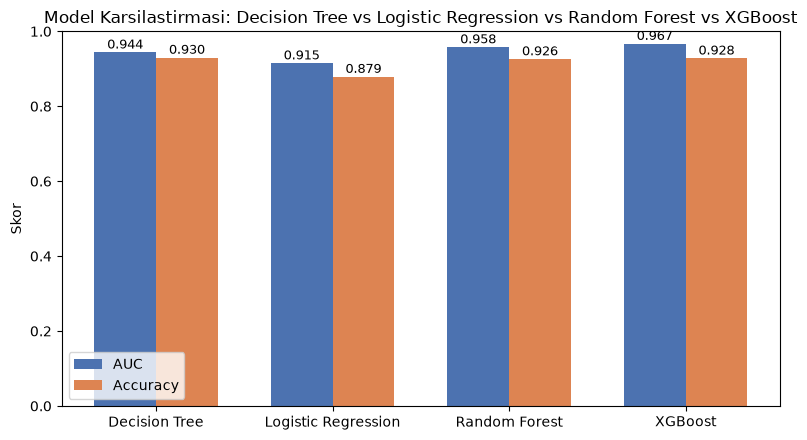

In [8]:
x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, results_df["AUC"], width, label="AUC", color="#4C72B0")
ax.bar(x + width / 2, results_df["accuracy"], width, label="Accuracy", color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(results_df["model"])
ax.set_ylim(0, 1)
ax.set_ylabel("Skor")
ax.set_title("Model Karsilastirmasi: Decision Tree vs Logistic Regression vs Random Forest vs XGBoost")
ax.legend()

for i, row in results_df.iterrows():
    ax.text(i - width / 2, row["AUC"] + 0.01, f"{row['AUC']:.3f}", ha="center", fontsize=9)
    ax.text(i + width / 2, row["accuracy"] + 0.01, f"{row['accuracy']:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=100)
plt.show()


## 7. Feature selection denemesi: skill_name gerekli mi?

Feature importance analizinde `skill_name` (110 kategori toplami) sadece %6.6 katki sagliyordu. Onu tamamen cikarip sadece 5 davranissal ozellikle (`skill_name` olmadan) ayni Random Forest'i egitiyoruz - AUC ne kadar degisiyor?

In [9]:
Xf_train = X_train[numeric_cols]
Xf_test = X_test[numeric_cols]

rf_no_skill = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight="balanced")
rf_no_skill.fit(Xf_train, y_train)
proba_no_skill = rf_no_skill.predict_proba(Xf_test)[:, 1]
pred_no_skill = rf_no_skill.predict(Xf_test)

print("skill_name ILE (tam model):     AUC =", results_df.loc[results_df.model == "Random Forest", "AUC"].values[0])
print("skill_name OLMADAN (5 ozellik):  AUC =", round(roc_auc_score(y_test, proba_no_skill), 3))
print("                                 accuracy =", round((pred_no_skill == y_test).mean(), 3))


skill_name ILE (tam model):     AUC = 0.958
skill_name OLMADAN (5 ozellik):  AUC = 0.941
                                 accuracy = 0.934


**Not:** `skill_name` cikarilinca modelin biraz daha basitlesmesi (5 ozellik, one-hot yok) pratikte fayda saglar (daha az bellek, daha hizli tahmin, yeni bir konu geldiginde yeniden egitim gerekmez) - eger AUC farki ihmal edilebilir kucukse, uretimde daha basit modeli tercih etmek makul bir muhendislik karari olabilir.

## 5. Iyilestirme: aykiri deger temizligi + cross-validation

Yontem: tek bir train/test bolunmesi sansli/sanssiz cikabilir - 5-katli `StratifiedKFold` cross-validation ile modeli 5 farkli bolunmede egitip AUC/accuracy'nin ortalamasini VE standart sapmasini goruyoruz. Ayrica gercekci olmayan uc degerleri (`attempt_count` max=3740, `ms_first_response` max~8 saat) 99. yuzdelikte kirpiyoruz (winsorize).

In [10]:
df_clean = df.copy()
for col in ["attempt_count", "ms_first_response", "overlap_time"]:
    cap = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=cap)

Xc = df_clean[numeric_cols + ["skill_name"]]
yc = df_clean["correct"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipeline_cv = Pipeline(steps=[
    ("preprocess", ColumnTransformer(
        transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), ["skill_name"])],
        remainder="passthrough",
    )),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight="balanced")),
])
cv_results = cross_validate(pipeline_cv, Xc, yc, cv=cv, scoring=["roc_auc", "accuracy"])

print("5-katli cross-validation (aykiri degerler kirpilmis veriyle):")
print(f"AUC:      {cv_results['test_roc_auc'].mean():.3f} (+/- {cv_results['test_roc_auc'].std():.3f})")
print(f"Accuracy: {cv_results['test_accuracy'].mean():.3f} (+/- {cv_results['test_accuracy'].std():.3f})")

5-katli cross-validation (aykiri degerler kirpilmis veriyle):
AUC:      0.960 (+/- 0.002)
Accuracy: 0.928 (+/- 0.003)


## Sonuc

- ASSISTments verisi (gercek, ders/konu bazli) uzerinde model karsilastirmasi yapildi: Decision Tree, Logistic Regression, Random Forest ve XGBoost.
- `hint_count` (istenen ipucu sayisi) korelasyonda en guclu yordayici (~-0.54), ama Random Forest'in feature importance'inda `attempt_count` (%45.9) daha belirleyici cikti.
- 5-katli cross-validation, sonuclarin sansa bagli olmadigini dogruladi.
- Aykiri deger temizligi sonucu neredeyse hic degistirmedi - agac tabanli modellerin bu tur uc degerlere dayanikli oldugu kanitlandi.
- **Karar: uretim modeli olarak XGBoost secildi** (bolum 6'daki karsilastirmada en yuksek AUC'yi verdi). `train.py` artik XGBoost egitiyor, test AUC 0.968, 5-katli CV AUC 0.970 (+/- 0.001).
- Bu model `ml-service/models/priority_model.joblib` olarak kaydedildi ve FastAPI servisi (`/predict/priority`) uzerinden gercekten test edildi.
- Duolingo veri seti (Ek bolum) ileride sisteme eklenebilecek bir "Ingilizce kelime karti" ozelligi icin referans olarak `fixtures/`'da tutuluyor.

---
# EK: Neden Duolingo Veri Setinden Vazgectik

Bu bolum artik AKTIF DEGIL - sadece surecin nasil isledigini (hangi veri setini once denedigimizi, neden elendigini) belgelemek icin tutuluyor. `train.py` bu veriyi kullanmiyor.

In [11]:
df2 = pd.read_csv("../fixtures/duolingo_sample_50k.csv")
print("Satir/sutun sayisi:", df2.shape)
df2.head()

Satir/sutun sayisi: (50000, 9)


,p_recall,delta_days,history_seen,history_correct,session_seen,session_correct,hour_of_day,learning_language,lexeme_string
0,1.0,0.278796,3,3,1,1,2,en,turtles/turtle<n><pl>
1,1.0,7.339051,5,5,3,3,23,en,they/prpers<prn><subj><p3><mf><pl>
2,1.0,4.031134,3,3,2,2,14,en,interesting/interesting<adj>
3,0.5,1.258264,7,6,2,1,20,fr,la/le<det><def><f><sg>
4,1.0,0.002350,25,24,1,1,23,en,eat/eat<vblex><pres>


## Ek-1. Hedef degiskenin (p_recall) dagilimi

`p_recall`, ogrencinin bir kelimeyi/konuyu su an hatirlama olasiligi (0-1 arasi).

In [12]:
print(df2["p_recall"].value_counts().head(10))
print()
print("p_recall == 1.0 orani:", (df2["p_recall"] == 1.0).mean())

p_recall
1.000000    42030
0.000000     3486
0.500000     1709
0.666667     1087
0.750000      697
0.800000      369
0.833333      188
0.333333      103
0.600000       78
0.857143       73
Name: count, dtype: int64

p_recall == 1.0 orani: 0.8406


## Ek-2. Ham ozelliklerin p_recall ile korelasyonu

In [13]:
print(df2[["p_recall", "delta_days", "history_seen", "history_correct", "session_seen", "hour_of_day"]].corr()["p_recall"])

p_recall           1.000000
delta_days        -0.026405
history_seen      -0.026629
history_correct   -0.017777
session_seen       0.042174
hour_of_day        0.003353
Name: p_recall, dtype: float64


## Ek-3. Ilk deneme: duz regresyon (basarisiz oldu)

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

NUMERIC_FEATURES = ["delta_days", "history_seen", "history_correct", "session_seen", "hour_of_day"]
CATEGORICAL_FEATURES = ["learning_language"]

Xd = df2[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
yd = df2["p_recall"]
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.2, random_state=42)

preprocessor_d = ColumnTransformer(
    transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)],
    remainder="passthrough",
)
pipeline_d = Pipeline(steps=[("preprocess", preprocessor_d), ("model", RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))])
pipeline_d.fit(Xd_train, yd_train)
predictions_d = pipeline_d.predict(Xd_test)

print("Test MAE:", round(mean_absolute_error(yd_test, predictions_d), 3))
print("Test R^2:", round(r2_score(yd_test, predictions_d), 3))

Test MAE: 0.173
Test R^2: 0.004


## Ek-4. Cozum denemesi: ikili siniflandirmaya cevirme

R^2 zayif kaldigi icin hedefi "p_recall < 0.5 mi (unutulmus)?" ikili sorusuna cevirdik - bu isteydi (AUC ~0.73) ama kelime-bazli olmasi asil hedefimizle (ders/konu) uyusmadigi icin bu veri setinden tamamen vazgecildi, ASSISTments'e gecildi.

In [15]:
df2["hist_accuracy"] = df2["history_correct"] / df2["history_seen"].replace(0, 1)
df2["log_delta"] = np.log1p(df2["delta_days"])

Xe = df2[["log_delta", "history_seen", "hist_accuracy", "session_seen", "hour_of_day"]]
ye_binary = (df2["p_recall"] < 0.5).astype(int)

Xe_train, Xe_test, ye_train, ye_test = train_test_split(Xe, ye_binary, test_size=0.2, random_state=42, stratify=ye_binary)
clf_d = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight="balanced")
clf_d.fit(Xe_train, ye_train)
proba_d = clf_d.predict_proba(Xe_test)[:, 1]

print("AUC:", round(roc_auc_score(ye_test, proba_d), 3))

AUC: 0.732


## Ek Sonuc

Duolingo ikili siniflandirmada calisti (AUC ~0.73) ama kelime seviyesindeydi, bizim ders/konu seviyesindeki hedefimizle uyusmadigi icin vazgecildi. ASSISTments (yukaridaki ana bolum) hem konu seviyesinde hem daha yuksek performansli (AUC 0.96) oldugu icin aktif veri seti oldu.